# A Classification Workflow with Heart Disease Dataset

This notebook follows the same structure as the regression workflow to build and compare **six classification models** for predicting whether a patient has heart disease.

Dataset columns:
- `age` – age in years
- `sex` – 1 = male, 0 = female
- `cp` – chest pain type (0–3)
- `trestbps` – resting blood pressure (mm Hg)
- `chol` – serum cholesterol (mg/dl)
- `fbs` – fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
- `restecg` – resting ECG results (0–2)
- `thalach` – maximum heart rate achieved
- `exang` – exercise-induced angina (1 = yes, 0 = no)
- `oldpeak` – ST depression induced by exercise
- `slope` – slope of the peak exercise ST segment (0–2)
- `ca` – number of major vessels coloured by fluoroscopy (0–3)
- `thal` – thalassemia (1 = normal, 2 = fixed defect, 3 = reversible defect)
- `target` – **label**: 1 = heart disease present, 0 = no heart disease

Workflow:
1. Get the data ready
2. Choose the model/estimator
3. Fit the model to the data and use it to make a prediction
4. Evaluate the model
5. Experiment to improve (hyperparameter tuning)
6. Save a model for later use

In [1]:
# Standard imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## 1. Get the data ready

In [2]:
# Load the dataset
heart = pd.read_csv("heart-disease.csv")

# View first rows
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Check shape and data types
print(f"Shape: {heart.shape}")
heart.dtypes

Shape: (303, 14)


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [4]:
heart.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
# Check for missing values
heart.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

target
1    165
0    138
Name: count, dtype: int64


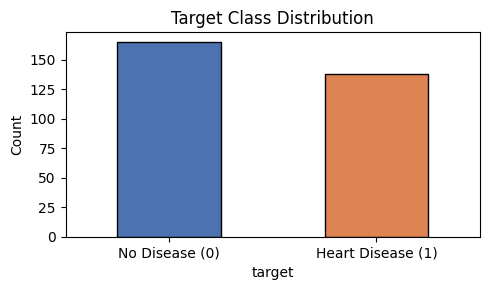

In [7]:
# Check target distribution
print(heart["target"].value_counts())

heart["target"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"],
                                     edgecolor="black", figsize=(5, 3))
plt.xticks([0, 1], ["No Disease (0)", "Heart Disease (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Target Class Distribution")
plt.tight_layout()
plt.show()

All columns are already numeric — no encoding is needed. We can go straight to creating `X` and `y`.

In [8]:
# Create X (features) and y (target)
X = heart.drop("target", axis=1)
y = heart["target"]

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

Features shape: (303, 13)
Target shape:   (303,)


In [9]:
# Split into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((242, 13), (61, 13), (242,), (61,))

## 2. Choose the model/estimator

Since this is a **binary classification** problem (heart disease: yes/no), we compare six classic classifiers:

| Model | Key idea |
|---|---|
| **Logistic Regression** | Linear decision boundary; models log-odds of the positive class |
| **KNN** | Predicts based on the majority label among the *k* nearest neighbours |
| **Naive Bayes** | Probabilistic; assumes feature independence given the class |
| **Decision Tree** | Splits feature space into rectangular regions via learned rules |
| **Random Forest** | Ensemble of many decorrelated decision trees; reduces variance |
| **SVM** | Finds the maximum-margin hyperplane separating the classes |

In [10]:
# Import all six classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Collect them in an ordered dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN":                  KNeighborsClassifier(),
    "Naive Bayes":          GaussianNB(),
    "Decision Tree":        DecisionTreeClassifier(random_state=42),
    "Random Forest":        RandomForestClassifier(random_state=42),
    "SVM":                  SVC(probability=True, random_state=42),
}

## 3. Fit the model to the data and use it to make a prediction

In [11]:
# Fit every model and store its predictions
model_preds = {}
model_probs = {}   # for ROC curves

for name, model in models.items():
    model.fit(X_train, y_train)
    model_preds[name] = model.predict(X_test)
    model_probs[name] = model.predict_proba(X_test)[:, 1]
    print(f"Fitted: {name}")

Fitted: Logistic Regression
Fitted: KNN
Fitted: Naive Bayes
Fitted: Decision Tree
Fitted: Random Forest
Fitted: SVM


C:\00code\Course\Data\project\MachineLearning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# Preview predictions vs actuals for the first 10 test samples
preview = pd.DataFrame({"Actual": y_test.values[:10]})
for name, preds in model_preds.items():
    preview[name] = preds[:10]
preview

,Actual,Logistic Regression,KNN,Naive Bayes,Decision Tree,Random Forest,SVM
0,0,0,0,0,0,0,0
1,0,1,1,1,0,1,1
2,1,1,1,1,0,1,1
3,0,0,1,0,1,0,1
4,1,1,0,1,1,1,0
5,1,1,1,1,0,1,1
6,1,1,1,1,1,1,1
7,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0
9,1,1,1,1,1,0,1


## 4. Evaluate the model

For classification problems we use:
- **Accuracy** – fraction of correct predictions (misleading on imbalanced data)
- **Precision** – of predicted positives, how many are actually positive
- **Recall** – of actual positives, how many were correctly predicted
- **F1 Score** – harmonic mean of precision and recall
- **ROC-AUC** – area under the Receiver Operating Characteristic curve; 1.0 = perfect

In [13]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

results = {}
for name in models:
    y_preds = model_preds[name]
    y_probs = model_probs[name]
    results[name] = {
        "Accuracy":  accuracy_score(y_test, y_preds),
        "Precision": precision_score(y_test, y_preds),
        "Recall":    recall_score(y_test, y_preds),
        "F1 Score":  f1_score(y_test, y_preds),
        "ROC-AUC":   roc_auc_score(y_test, y_probs),
    }

results_df = pd.DataFrame(results).T.sort_values("F1 Score", ascending=False)
results_df.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.8852,0.8788,0.9062,0.8923,0.9267
Naive Bayes,0.8689,0.9000,0.8438,0.8710,0.8944
Random Forest,0.8361,0.8438,0.8438,0.8438,0.9203
SVM,0.7049,0.6667,0.8750,0.7568,0.8394
Decision Tree,0.7541,0.8400,0.6562,0.7368,0.7592
KNN,0.6885,0.6857,0.7500,0.7164,0.7613


C:\Users\awang\AppData\Local\Temp\ipykernel_57248\1656875662.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=25, ha='right', fontsize=8)
C:\Users\awang\AppData\Local\Temp\ipykernel_57248\1656875662.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=25, ha='right', fontsize=8)
C:\Users\awang\AppData\Local\Temp\ipykernel_57248\1656875662.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=25, ha='right', fontsize=8)
C:\Users\awang\AppData\Local\Temp\ipykernel_57248\1656875662.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.s

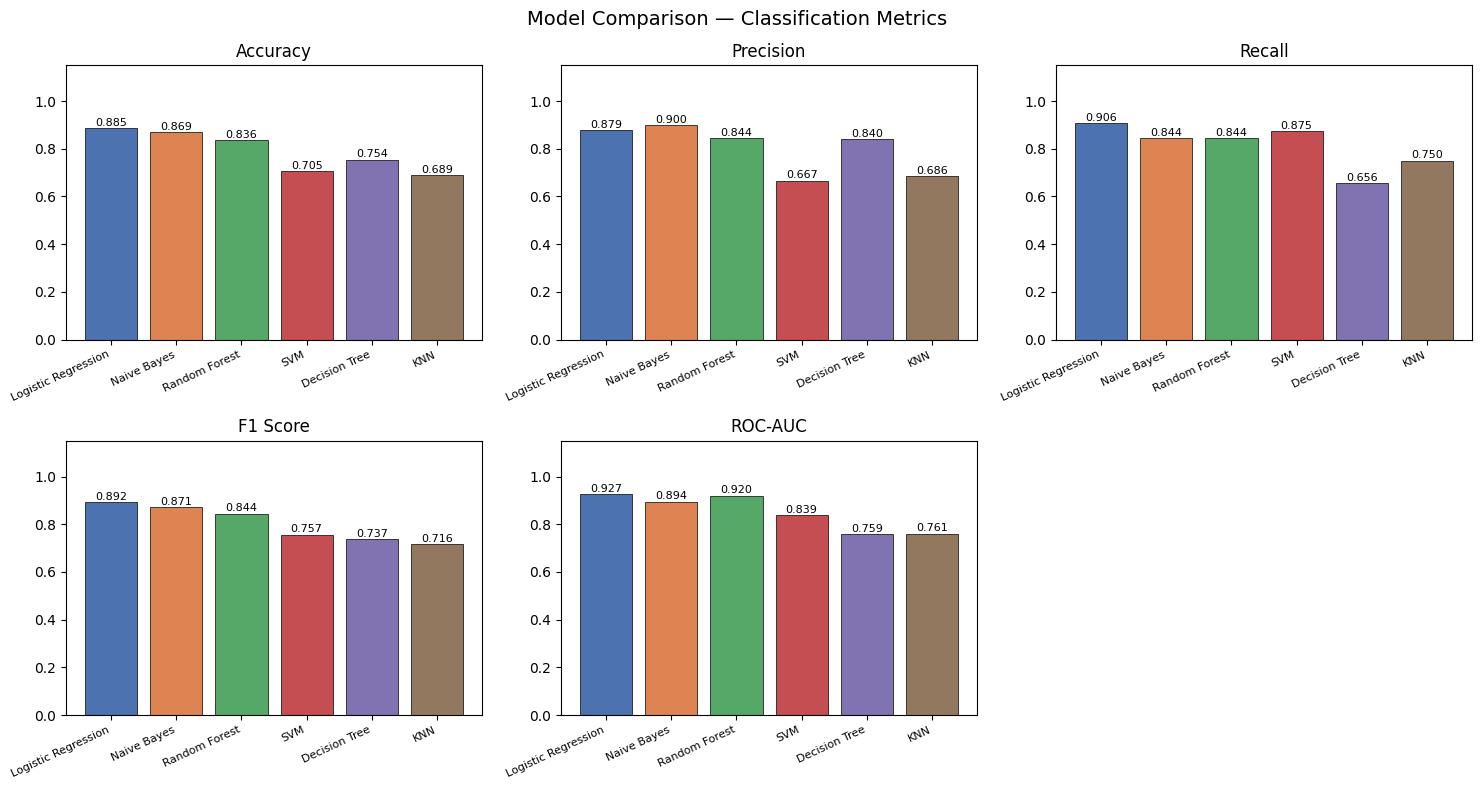

In [14]:
# Bar chart comparison across all five metrics
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes_flat[i]
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(vals.index, rotation=25, ha='right', fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", fontsize=8)

# Hide the unused 6th subplot
axes_flat[-1].set_visible(False)

plt.suptitle("Model Comparison — Classification Metrics", fontsize=14)
plt.tight_layout()
plt.show()

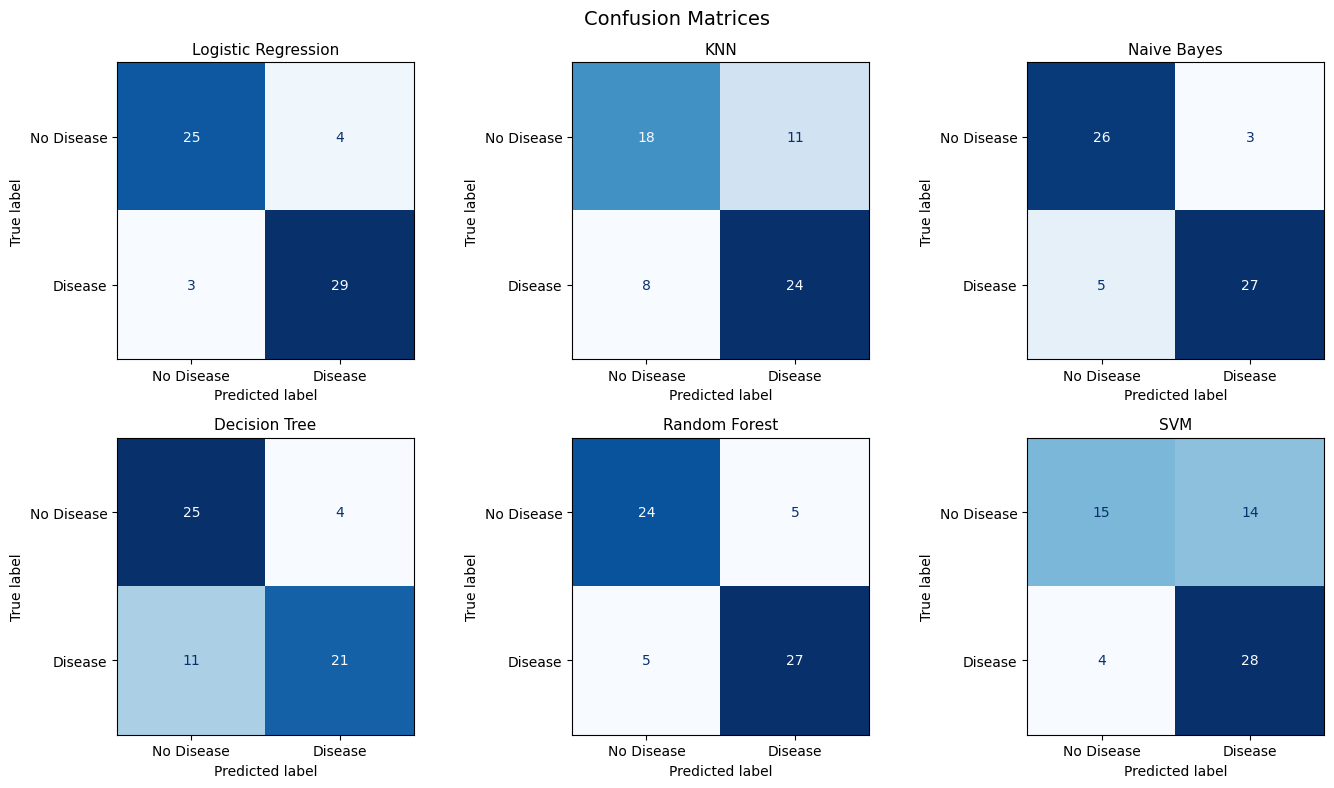

In [15]:
# Confusion matrices for all six models
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (name, model) in zip(axes.flatten(), models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["No Disease", "Disease"],
        colorbar=False, cmap="Blues", ax=ax
    )
    ax.set_title(name, fontsize=11)

plt.suptitle("Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()

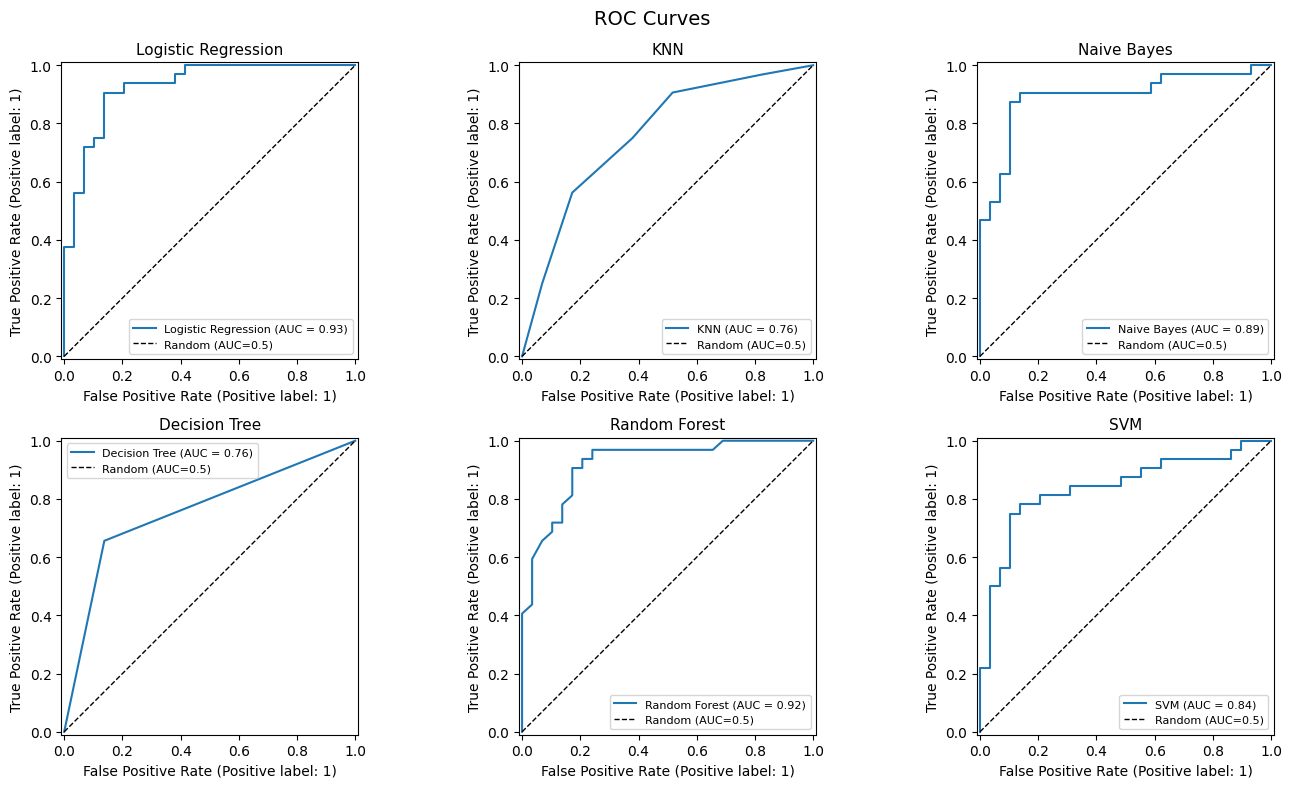

In [16]:
# ROC curves for all six models
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (name, model) in zip(axes.flatten(), models.items()):
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle("ROC Curves", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Experiment to improve (hyperparameter tuning)

First, use **5-fold cross-validation** on the full dataset to get a more reliable accuracy estimate for each model. Then apply `RandomizedSearchCV` to tune the best-performing ensemble model.

In [17]:
from sklearn.model_selection import cross_val_score

print(f"{'Model':<25} {'CV Accuracy':>12}  {'± Std':>8}")
print("-" * 52)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    cv_results[name] = scores.mean()
    print(f"{name:<25}  {scores.mean():.4f}  ±  {scores.std():.4f}")

best_cv_model = max(cv_results, key=cv_results.get)
print(f"\nBest model by CV Accuracy: {best_cv_model}")

Model                      CV Accuracy     ± Std
----------------------------------------------------
Logistic Regression        0.8283  ±  0.0457
KNN                        0.6439  ±  0.0538
Naive Bayes                0.8051  ±  0.0555
Decision Tree              0.7555  ±  0.0529
Random Forest              0.8382  ±  0.0288
SVM                        0.6435  ±  0.0580

Best model by CV Accuracy: Random Forest


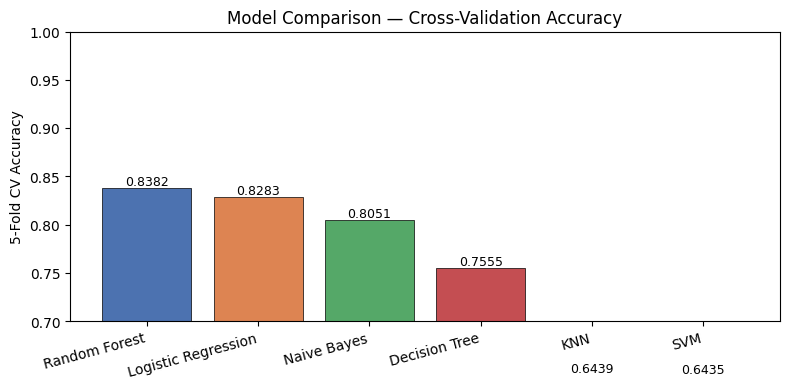

In [18]:
# Visualise cross-validation accuracies
cv_df = pd.Series(cv_results).sort_values(ascending=False)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

plt.figure(figsize=(8, 4))
bars = plt.bar(cv_df.index, cv_df.values, color=colors, edgecolor='black', linewidth=0.5)
plt.ylabel("5-Fold CV Accuracy")
plt.title("Model Comparison — Cross-Validation Accuracy")
plt.ylim(0.7, 1.0)
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, cv_df.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f"{val:.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [19]:
# Tune Random Forest with RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators":     [50, 100, 200, 300],
    "max_depth":        [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":     ["sqrt", "log2"],
}

rf = RandomForestClassifier(random_state=42)
rs_cv = RandomizedSearchCV(
    rf, param_grid, n_iter=20, cv=5,
    scoring="accuracy", n_jobs=-1, random_state=42
)
rs_cv.fit(X_train, y_train)

print(f"Best params:      {rs_cv.best_params_}")
print(f"Best CV accuracy: {rs_cv.best_score_:.4f}")
print(f"Test accuracy:    {rs_cv.score(X_test, y_test):.4f}")

Best params:      {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}
Best CV accuracy: 0.8222
Test accuracy:    0.8689


In [20]:
# Compare baseline vs tuned Random Forest
tuned_preds    = rs_cv.predict(X_test)
baseline_preds = model_preds["Random Forest"]

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline RF": [
        accuracy_score(y_test,  baseline_preds),
        precision_score(y_test, baseline_preds),
        recall_score(y_test,    baseline_preds),
        f1_score(y_test,        baseline_preds),
    ],
    "Tuned RF": [
        accuracy_score(y_test,  tuned_preds),
        precision_score(y_test, tuned_preds),
        recall_score(y_test,    tuned_preds),
        f1_score(y_test,        tuned_preds),
    ],
}).set_index("Metric")

comparison.round(4)

,Baseline RF,Tuned RF
Metric,,
Accuracy,0.8361,0.8689
Precision,0.8438,0.8750
Recall,0.8438,0.8750
F1 Score,0.8438,0.8750


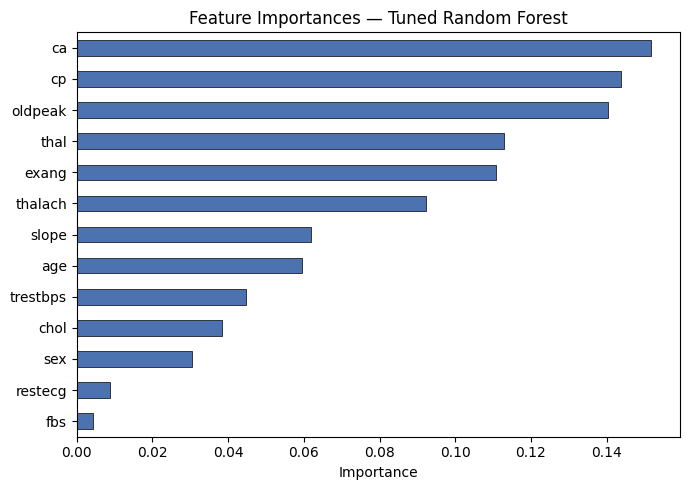

In [21]:
# Feature importances from tuned Random Forest
best_rf = rs_cv.best_estimator_
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

feat_imp.plot(kind="barh", figsize=(7, 5), color="#4C72B0", edgecolor="black", linewidth=0.5)
plt.xlabel("Importance")
plt.title("Feature Importances — Tuned Random Forest")
plt.tight_layout()
plt.show()

## 6. Save a model for later use

We save the tuned Random Forest to disk with `pickle` so it can be loaded and used in production without retraining.

In [22]:
import pickle

filename = "heart_disease_rf_model.pkl"
pickle.dump(best_rf, open(filename, "wb"))
print(f"Model saved as '{filename}'")

Model saved as 'heart_disease_rf_model.pkl'


In [23]:
# Load the saved model and make a prediction on a single example
loaded_model = pickle.load(open("heart_disease_rf_model.pkl", "rb"))

single_sample = X_test.iloc[[0]]
prediction    = loaded_model.predict(single_sample)[0]
actual        = y_test.iloc[0]

print(f"Prediction: {'Heart Disease' if prediction == 1 else 'No Disease'}")
print(f"Actual:     {'Heart Disease' if actual == 1 else 'No Disease'}")
print(f"Correct:    {prediction == actual}")

Prediction: No Disease
Actual:     No Disease
Correct:    True
